Running symmetric noise sweep...
Running biased noise sweep...

=== Symmetric noise summary ===


,algo,noise_type,alpha,mean_simple_regret,std_simple_regret,mean_top1_acc,mean_topk_acc,mean_cum_regret,std_cum_regret
0,GP-PBO,sym,0.00,10.83548,4.560739,0.1,0.0,1650.67730,591.107953
1,GP-PBO,sym,0.05,10.83548,4.560739,0.1,0.0,1650.67730,591.107953
2,GP-PBO,sym,0.10,10.22714,5.469260,0.2,0.0,1543.60946,752.927369
3,GP-PBO,sym,0.20,10.22714,5.469260,0.2,0.0,1543.60946,752.927369
4,Exp3,sym,0.00,0.00000,0.000000,1.0,0.9,1166.14282,111.857350
5,Exp3,sym,0.05,0.00000,0.000000,1.0,0.7,1211.04378,109.529475
6,Exp3,sym,0.10,0.60834,1.825020,0.9,0.5,1241.79276,100.398526
7,Exp3,sym,0.20,2.13612,3.360393,0.7,0.6,1368.73714,90.320931



=== Biased noise summary ===


,algo,noise_type,alpha,mean_simple_regret,std_simple_regret,mean_top1_acc,mean_topk_acc,mean_cum_regret,std_cum_regret
0,GP-PBO,biased,0.00,10.83548,4.560739,0.1,0.0,1650.67730,591.107953
1,GP-PBO,biased,0.05,10.83548,4.560739,0.1,0.0,1650.67730,591.107953
2,GP-PBO,biased,0.10,10.83548,4.560739,0.1,0.0,1650.67730,591.107953
3,GP-PBO,biased,0.20,10.83548,4.560739,0.1,0.0,1650.67730,591.107953
4,Exp3,biased,0.00,0.00000,0.000000,1.0,0.9,1166.14282,111.857350
5,Exp3,biased,0.05,0.91944,2.758320,0.9,0.9,1233.38292,105.372905
6,Exp3,biased,0.10,1.83888,3.677760,0.8,0.8,1282.30430,126.078586
7,Exp3,biased,0.20,6.09726,2.374078,0.1,0.8,1351.73440,104.734487


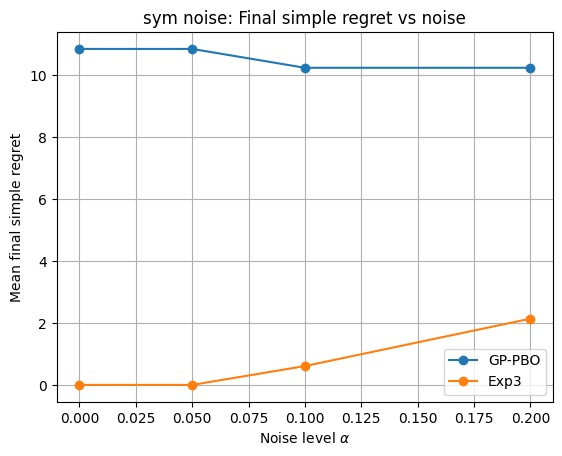

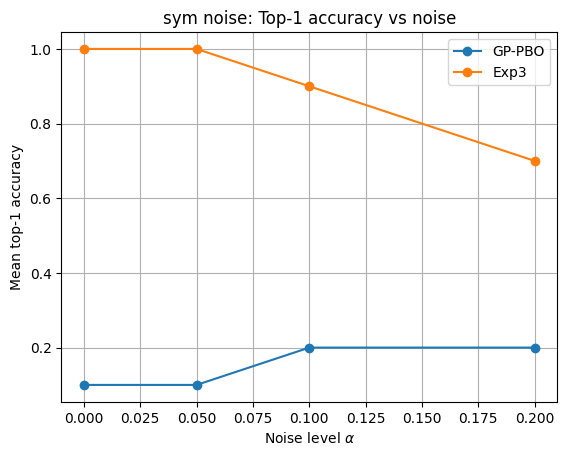

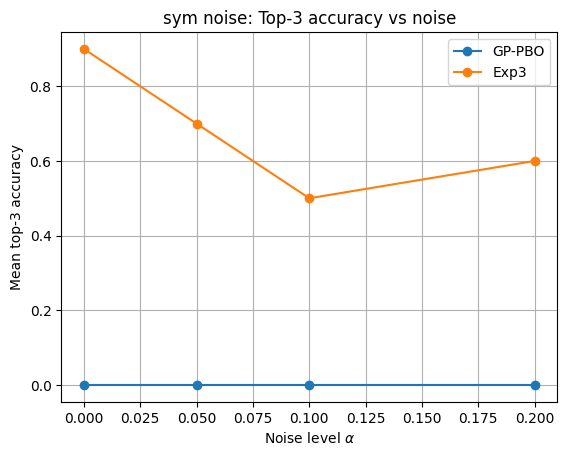

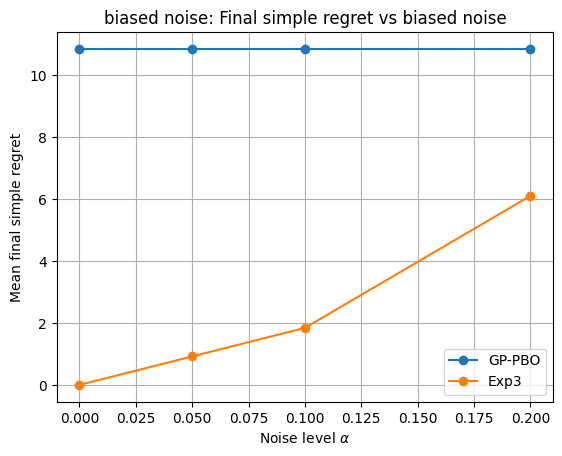

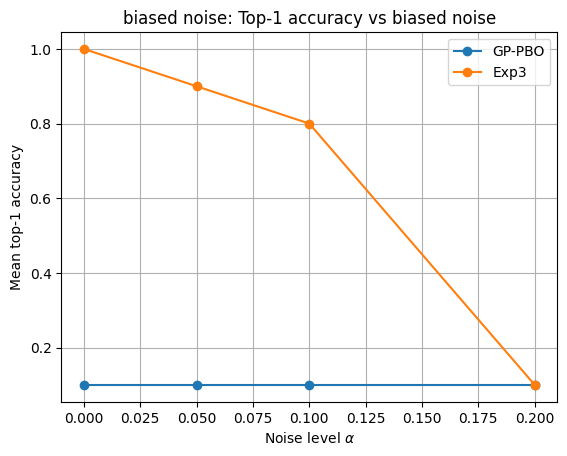

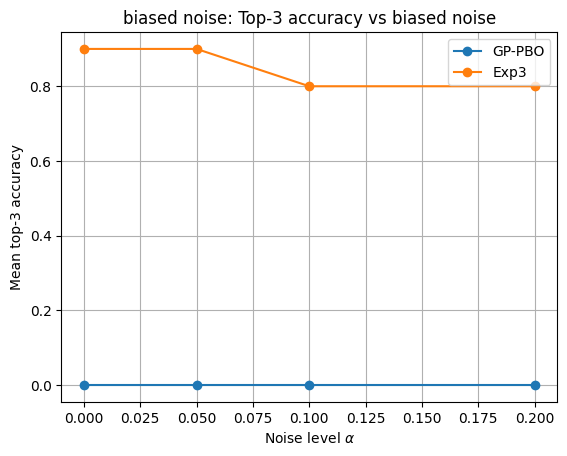

In [2]:
import numpy as np
import torch
import pandas as pd
import matplotlib.pyplot as plt

from botorch.models.pairwise_gp import PairwiseGP, PairwiseLaplaceMarginalLogLikelihood
from botorch.fit import fit_gpytorch_mll

# ------------------------------------------------------------
# 0) Build true utilities and item features from rankings
# ------------------------------------------------------------
# If rankings is NOT defined yet, uncomment and adapt:
rankings = np.loadtxt("sushi3a.5000.10.order", dtype=int, skiprows=1)

num_users, num_items = rankings.shape

# Borda-style utility from rankings
borda_scores = np.zeros(num_items, dtype=float)
for u in range(num_users):
    ranking = rankings[u]  # permutation of 0..num_items-1
    for pos, item in enumerate(ranking):
        borda_scores[item] += num_items - 1 - pos  # top gets num_items-1, bottom 0

true_utils = borda_scores / num_users
true_utils_torch = torch.tensor(true_utils, dtype=torch.float64)

# Simple 1D feature: normalized item index in [0, 1]
item_features = torch.arange(num_items, dtype=torch.float64).unsqueeze(-1) / (num_items - 1)


# ------------------------------------------------------------
# 1) Preference Oracle with noise strategies
# ------------------------------------------------------------
class PreferenceOracle:
    def __init__(self, utils, strategy="none", alpha=0.0, bias_item=None, rng=None):
        """
        utils: array-like, true utility for each item
        strategy:
            "none"   -> honest oracle (no noise)
            "sym"    -> symmetric label noise (flip outcome with prob alpha)
            "biased" -> biased *against* `bias_item` when present in the pair
                        (if bias_item is in the pair, with prob alpha, force the other to win)
        alpha: noise strength (0.0 to 1.0)
        bias_item: index of item that noise is biased against (for "biased" strategy)
        """
        self.utils = np.asarray(utils, dtype=float)
        self.strategy = strategy
        self.alpha = float(alpha)
        self.bias_item = bias_item
        self.rng = np.random.default_rng() if rng is None else rng

    def compare(self, i, j):
        """Return observed winner index (i or j) under the chosen noise model."""
        ui, uj = self.utils[i], self.utils[j]

        # True winner from utilities
        if ui > uj:
            winner_true = i
        elif uj > ui:
            winner_true = j
        else:
            winner_true = int(self.rng.choice([i, j]))

        # No noise
        if self.strategy == "none":
            return winner_true

        # Symmetric label noise: flip true winner with probability alpha
        if self.strategy == "sym":
            if self.rng.random() < self.alpha:
                return j if winner_true == i else i
            else:
                return winner_true

        # Biased noise: if bias_item is in the pair, sometimes force the *other* to win
        if self.strategy == "biased":
            if self.bias_item is not None and (i == self.bias_item or j == self.bias_item):
                if self.rng.random() < self.alpha:
                    # Force the non-bias item to win
                    return j if self.bias_item == i else i
            return winner_true

        # Fallback (shouldn't happen)
        return winner_true


# ------------------------------------------------------------
# 2) GP-PBO agent (Pairwise GP with partial refitting)
# ------------------------------------------------------------
class GPPBO:
    def __init__(self, num_items, item_features, refit_every=5):
        """
        num_items: number of items
        item_features: torch tensor of shape (num_items, d)
        refit_every: refit GP after this many new comparisons (to save time)
        """
        self.num_items = num_items
        self.item_features = item_features.double()
        self.gp_model = None
        self.mll = None
        self.comparisons = []  # list of [winner, loser]
        self.refit_every = refit_every
        self.last_fit_n = 0

    def select_pair(self):
        # Simple heuristic: random at start, then "best" vs random challenger
        if self.gp_model is None or len(self.comparisons) < 5:
            i, j = np.random.choice(self.num_items, size=2, replace=False)
            return int(i), int(j)

        with torch.no_grad():
            post = self.gp_model.posterior(self.item_features)
            mean = post.mean.view(-1).cpu().numpy()
        best = int(np.argmax(mean))
        candidates = list(range(self.num_items))
        candidates.remove(best)
        challenger = int(np.random.choice(candidates))
        return best, challenger

    def record_result(self, i, j, winner):
        if winner == i:
            self.comparisons.append([i, j])
        elif winner == j:
            self.comparisons.append([j, i])
        else:
            raise ValueError("winner must be either i or j")

    def update_model(self):
        """
        Fit / refit PairwiseGP on collected comparisons.
        Refits only if enough new comparisons have been added (refit_every).
        """
        n = len(self.comparisons)
        if n == 0:
            return
        if self.gp_model is not None and n - self.last_fit_n < self.refit_every:
            return  # skip refit for efficiency

        train_X = self.item_features
        train_comp = torch.tensor(self.comparisons, dtype=torch.long)

        if self.gp_model is None:
            self.gp_model = PairwiseGP(train_X, train_comp)
        else:
            # Update comparisons only; X is fixed
            self.gp_model.set_train_data(comparisons=train_comp, strict=False)

        self.mll = PairwiseLaplaceMarginalLogLikelihood(
            self.gp_model.likelihood, self.gp_model
        )

        try:
            fit_gpytorch_mll(self.mll)
        except Exception as e:
            print(f"[Warning] GP fit failed at n={n} comps with error: {e}")

        self.last_fit_n = n


# ------------------------------------------------------------
# 3) Exp3-based dueling agent
# ------------------------------------------------------------
class Exp3Dueling:
    def __init__(self, num_items, gamma=0.1):
        self.num_items = num_items
        self.gamma = float(gamma)
        self.weights = np.ones(num_items, dtype=float)

    def _get_probs(self):
        w = self.weights
        p = (1.0 - self.gamma) * (w / w.sum()) + self.gamma / self.num_items
        return p

    def select_pair(self):
        p = self._get_probs()
        i = np.random.choice(self.num_items, p=p)
        p2 = p.copy()
        p2[i] = 0.0
        p2 /= p2.sum()
        j = np.random.choice(self.num_items, p=p2)
        return int(i), int(j)

    def record_result(self, i, j, winner):
        p = self._get_probs()
        pw = p[winner]
        r_hat = 1.0 / pw
        eta = self.gamma / self.num_items
        self.weights[winner] *= np.exp(eta * r_hat)

    def get_probs(self):
        return self._get_probs()


# ------------------------------------------------------------
# 4) Helpers and simulation
# ------------------------------------------------------------
def top_k_from_scores(scores, k):
    scores = np.asarray(scores)
    idx = np.argsort(-scores)[:k]
    return set(idx.tolist())


def run_simulation(oracle, algo_type="GP-PBO", iterations=200, top_k=3):
    """
    oracle: PreferenceOracle
    algo_type: "GP-PBO" or "Exp3"
    iterations: number of duels
    top_k: define target top-k set from true utils
    """
    num_items = len(oracle.utils)
    true_topk = top_k_from_scores(oracle.utils, top_k)
    true_best = int(np.argmax(oracle.utils))

    if algo_type == "GP-PBO":
        agent = GPPBO(num_items, item_features)
    elif algo_type == "Exp3":
        agent = Exp3Dueling(num_items)
    else:
        raise ValueError(f"Unknown algo_type: {algo_type}")

    topk_found_at = None
    history = {"iteration": [], "regret": []}
    est_scores = np.zeros(num_items)

    for t in range(1, iterations + 1):
        i, j = agent.select_pair()
        winner = oracle.compare(i, j)
        agent.record_result(i, j, winner)

        # Update and get current score estimate
        if algo_type == "GP-PBO":
            agent.update_model()
            if agent.gp_model is not None:
                with torch.no_grad():
                    post = agent.gp_model.posterior(item_features)
                    est_scores = post.mean.view(-1).cpu().numpy()
        else:
            est_scores = agent.get_probs()

        # Track when we first get the correct top-k
        est_topk = top_k_from_scores(est_scores, top_k)
        if est_topk == true_topk and topk_found_at is None:
            topk_found_at = t

        # Instantaneous regret (vs true utilities)
        best_u = float(np.max(oracle.utils))
        chosen_u = float(max(oracle.utils[i], oracle.utils[j]))
        regret = best_u - chosen_u
        history["iteration"].append(t)
        history["regret"].append(regret)

    final_best = int(np.argmax(est_scores))
    final_simple_regret = float(np.max(oracle.utils) - oracle.utils[final_best])

    return {
        "algo_type": algo_type,
        "history": history,
        "topk_found_at": topk_found_at,
        "final_scores": est_scores,
        "true_topk": true_topk,
        "true_best": true_best,
        "final_best": final_best,
        "final_simple_regret": final_simple_regret,
    }


# ------------------------------------------------------------
# 5) Sweep over noise levels for symmetric or biased noise
# ------------------------------------------------------------
def run_noise_sweep(noise_strategy, alphas, iterations=200, top_k=3, num_seeds=10):
    """
    noise_strategy: "sym" or "biased"
    alphas: list of noise levels to try
    """
    results = []
    true_topk = top_k_from_scores(true_utils, top_k)
    true_best = int(np.argmax(true_utils))

    for algo_type in ["GP-PBO", "Exp3"]:
        for alpha in alphas:
            simple_regrets = []
            top1_correct = []
            topk_correct = []
            cum_regrets = []

            for seed in range(num_seeds):
                # Per-run seed for reproducibility
                np.random.seed(seed)
                torch.manual_seed(seed)

                bias_item = None
                if noise_strategy == "biased":
                    bias_item = true_best  # biased *against* the true best item

                rng = np.random.default_rng(seed)
                oracle = PreferenceOracle(
                    true_utils,
                    strategy=noise_strategy,
                    alpha=alpha,
                    bias_item=bias_item,
                    rng=rng,
                )
                res = run_simulation(
                    oracle,
                    algo_type=algo_type,
                    iterations=iterations,
                    top_k=top_k,
                )

                simple_regrets.append(res["final_simple_regret"])
                top1_correct.append(int(res["final_best"] == true_best))
                est_topk = top_k_from_scores(res["final_scores"], top_k)
                topk_correct.append(int(est_topk == true_topk))
                cum_regrets.append(float(np.sum(res["history"]["regret"])))

            results.append({
                "algo": algo_type,
                "noise_type": noise_strategy,
                "alpha": alpha,
                "mean_simple_regret": float(np.mean(simple_regrets)),
                "std_simple_regret": float(np.std(simple_regrets)),
                "mean_top1_acc": float(np.mean(top1_correct)),
                "mean_topk_acc": float(np.mean(topk_correct)),
                "mean_cum_regret": float(np.mean(cum_regrets)),
                "std_cum_regret": float(np.std(cum_regrets)),
            })
    return results


# ------------------------------------------------------------
# 6) Run sweeps and build summary tables
# ------------------------------------------------------------
alphas = [0.0, 0.05, 0.1, 0.2]  # adjust as needed
iterations = 200                # adjust (more iterations = stronger results)
num_seeds = 10                  # increase for smoother curves (e.g., 20)

print("Running symmetric noise sweep...")
results_sym = run_noise_sweep("sym", alphas, iterations=iterations, top_k=3, num_seeds=num_seeds)
df_sym = pd.DataFrame(results_sym)

print("Running biased noise sweep...")
results_biased = run_noise_sweep("biased", alphas, iterations=iterations, top_k=3, num_seeds=num_seeds)
df_biased = pd.DataFrame(results_biased)

print("\n=== Symmetric noise summary ===")
display(df_sym)

print("\n=== Biased noise summary ===")
display(df_biased)


# ------------------------------------------------------------
# 7) Plotting helper
# ------------------------------------------------------------
def plot_metric_vs_alpha(df, noise_type, metric, ylabel, title_suffix, alphas):
    """
    df: DataFrame with columns ['algo', 'noise_type', 'alpha', metric]
    """
    df_nt = df[df["noise_type"] == noise_type]

    fig, ax = plt.subplots()

    for algo in ["GP-PBO", "Exp3"]:
        ys = []
        for a in alphas:
            row = df_nt[(df_nt["algo"] == algo) & (df_nt["alpha"] == a)]
            if len(row) == 0:
                ys.append(np.nan)
            else:
                ys.append(row.iloc[0][metric])
        ax.plot(alphas, ys, marker="o", label=algo)

    ax.set_xlabel(r"Noise level $\alpha$")
    ax.set_ylabel(ylabel)
    ax.set_title(f"{noise_type} noise: {title_suffix}")
    ax.grid(True)
    ax.legend()
    plt.show()


# ------------------------------------------------------------
# 8) Generate plots for paper-style figures
# ------------------------------------------------------------

# Symmetric noise
plot_metric_vs_alpha(
    df_sym,
    noise_type="sym",
    metric="mean_simple_regret",
    ylabel="Mean final simple regret",
    title_suffix="Final simple regret vs noise",
    alphas=alphas,
)

plot_metric_vs_alpha(
    df_sym,
    noise_type="sym",
    metric="mean_top1_acc",
    ylabel="Mean top-1 accuracy",
    title_suffix="Top-1 accuracy vs noise",
    alphas=alphas,
)

plot_metric_vs_alpha(
    df_sym,
    noise_type="sym",
    metric="mean_topk_acc",
    ylabel="Mean top-3 accuracy",
    title_suffix="Top-3 accuracy vs noise",
    alphas=alphas,
)

# Biased noise (biased against the true best item)
plot_metric_vs_alpha(
    df_biased,
    noise_type="biased",
    metric="mean_simple_regret",
    ylabel="Mean final simple regret",
    title_suffix="Final simple regret vs biased noise",
    alphas=alphas,
)

plot_metric_vs_alpha(
    df_biased,
    noise_type="biased",
    metric="mean_top1_acc",
    ylabel="Mean top-1 accuracy",
    title_suffix="Top-1 accuracy vs biased noise",
    alphas=alphas,
)

plot_metric_vs_alpha(
    df_biased,
    noise_type="biased",
    metric="mean_topk_acc",
    ylabel="Mean top-3 accuracy",
    title_suffix="Top-3 accuracy vs biased noise",
    alphas=alphas,
)


In [1]:
!pip install botorch gpytorch

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.4/3.4 MB 62.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 280.6/280.6 kB 27.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 176.3/176.3 kB 17.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 756.0/756.0 kB 56.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 55.9/55.9 kB 5.0 MB/s eta 0:00:00
